In [1]:
from pathlib import Path
from itertools import product
import random

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    TimeSeriesSplit
)

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error
)

import tensorflow as tf

from tensorflow.keras import Input
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber

In [2]:
TEST_RATIO = 0.1
SEED = 42
WINDOW_SIZE = 10
TOMORROW_SHIFT = -1

In [3]:
DATA_BASE_PATH = Path("./data")

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

tf.config.experimental.enable_op_determinism()

In [4]:
gold_file_path = DATA_BASE_PATH / "final_gold_data.csv"

gold = pd.read_csv(
    gold_file_path,
    sep=";",
    encoding="utf-8",
    parse_dates=["timestamp"]
)

In [5]:
gold["day_variation"] = (
    gold["open"] - gold["close"]
)

gold["max_diff"] = (
    gold["high"] - gold["low"]
)

gold["tomorrow_close"] = (
    gold["close"].shift(TOMORROW_SHIFT)
)

gold = gold.dropna(subset=["tomorrow_close"])

gold["target_return"] = (
    gold["tomorrow_close"] - gold["close"]
) / gold["close"]

gold["day_of_week"] = (
    gold["timestamp"].dt.dayofweek
)

gold["month"] = (
    gold["timestamp"].dt.month
)

In [6]:
delta = gold["close"].diff()

gain = delta.clip(lower=0)

loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()

avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

gold["rsi_14"] = (
    100 - (100 / (1 + rs))
)

In [7]:
gold = gold.dropna()

In [8]:
TARGET = "target_return"

to_drop = [
    "currency",
    "unit",
    "timestamp",
    "headlines",
    "tomorrow_close"
]

X = gold.drop(
    columns=to_drop + [TARGET]
)

In [9]:
y = gold[TARGET]

n_features = X.shape[1]

In [10]:
def create_sequences(X, y, window_size):

    Xs = []
    ys = []

    for i in range(len(X) - window_size):

        Xs.append(
            X[i:i + window_size]
        )

        ys.append(
            y.iloc[i + window_size]
        )

    return np.array(Xs), np.array(ys)

In [11]:
X_seq, y_seq = create_sequences(
    X.to_numpy(),
    y,
    WINDOW_SIZE
)

In [12]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_seq,
    y_seq,
    test_size=TEST_RATIO,
    shuffle=False
)

In [13]:
def build_model(
    filters=32,
    kernel_size=3,
    lstm_units=32,
    dropout_rate=0.2,
    dense_units=16,
    learning_rate=0.001
):

    model = Sequential()

    model.add(
        Input(
            shape=(WINDOW_SIZE, n_features)
        )
    )

    model.add(
        Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            activation="relu"
        )
    )

    model.add(
        MaxPooling1D(pool_size=2)
    )

    model.add(
        LSTM(lstm_units)
    )

    model.add(
        Dropout(dropout_rate)
    )

    model.add(
        Dense(
            dense_units,
            activation='relu'
        )
    )

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss=Huber()
    )

    return model

In [14]:
param_grid = {
    "filters": [32],
    "kernel_size": [3],
    "lstm_units": [32, 64],
    "dropout_rate": [0.2],
    "dense_units": [16],
    "learning_rate": [0.001, 0.0005],
    "batch_size": [32]
}

tscv = TimeSeriesSplit(n_splits=5)

results = []

combinations = list(product(
    param_grid["filters"],
    param_grid["kernel_size"],
    param_grid["lstm_units"],
    param_grid["dropout_rate"],
    param_grid["dense_units"],
    param_grid["learning_rate"],
    param_grid["batch_size"]
))

In [15]:
for (
    filters,
    kernel_size,
    lstm_units,
    dropout_rate,
    dense_units,
    learning_rate,
    batch_size
) in combinations:

    print("=" * 60)

    print(
        filters,
        kernel_size,
        lstm_units,
        dropout_rate,
        dense_units,
        learning_rate,
        batch_size
    )

    fold_rmses = []

    for train_idx, val_idx in tscv.split(X_train_full):

        X_train_cv = X_train_full[train_idx]
        X_val_cv = X_train_full[val_idx]

        y_train_cv = y_train_full[train_idx]
        y_val_cv = y_train_full[val_idx]

        scaler = StandardScaler()

        X_train_2d = X_train_cv.reshape(
            -1,
            n_features
        )

        X_val_2d = X_val_cv.reshape(
            -1,
            n_features
        )

        X_train_scaled = scaler.fit_transform(
            X_train_2d
        )

        X_val_scaled = scaler.transform(
            X_val_2d
        )

        X_train_scaled = X_train_scaled.reshape(
            X_train_cv.shape
        )

        X_val_scaled = X_val_scaled.reshape(
            X_val_cv.shape
        )

        tf.keras.backend.clear_session()

        model = build_model(
            filters=filters,
            kernel_size=kernel_size,
            lstm_units=lstm_units,
            dropout_rate=dropout_rate,
            dense_units=dense_units,
            learning_rate=learning_rate
        )

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )

        model.fit(
            X_train_scaled,
            y_train_cv,
            validation_data=(
                X_val_scaled,
                y_val_cv
            ),
            epochs=100,
            batch_size=batch_size,
            callbacks=[early_stop],
            shuffle=False,
            verbose=0
        )

        y_pred = model.predict(
            X_val_scaled,
            verbose=0
        )

        rmse = root_mean_squared_error(
            y_val_cv,
            y_pred
        )

        fold_rmses.append(rmse)

    mean_rmse = np.mean(fold_rmses)

    results.append({
        "filters": filters,
        "kernel_size": kernel_size,
        "lstm_units": lstm_units,
        "dropout_rate": dropout_rate,
        "dense_units": dense_units,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "rmse": mean_rmse
    })

    print("Mean RMSE:", mean_rmse)

32 3 32 0.2 16 0.001 32

Mean RMSE: 0.011104923492797413
32 3 32 0.2 16 0.0005 32
Mean RMSE: 0.011136633883881957
32 3 64 0.2 16 0.001 32
Mean RMSE: 0.0111054261020537
32 3 64 0.2 16 0.0005 32
Mean RMSE: 0.011097667071007627


In [16]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="rmse",
    ascending=True
)

In [17]:
print(results_df.head())

   filters  kernel_size  lstm_units  dropout_rate  dense_units  learning_rate  \
3       32            3          64           0.2           16         0.0005   
0       32            3          32           0.2           16         0.0010   
2       32            3          64           0.2           16         0.0010   
1       32            3          32           0.2           16         0.0005   

   batch_size      rmse  
3          32  0.011098  
0          32  0.011105  
2          32  0.011105  
1          32  0.011137  


In [18]:
best = results_df.iloc[0]

print("\nBEST PARAMS:\n")
print(best)


BEST PARAMS:

filters          32.000000
kernel_size       3.000000
lstm_units       64.000000
dropout_rate      0.200000
dense_units      16.000000
learning_rate     0.000500
batch_size       32.000000
rmse              0.011098
Name: 3, dtype: float64


In [19]:
scaler = StandardScaler()

X_train_2d = X_train_full.reshape(
    -1,
    n_features
)

X_test_2d = X_test.reshape(
    -1,
    n_features
)

X_train_scaled = scaler.fit_transform(
    X_train_2d
)

X_test_scaled = scaler.transform(
    X_test_2d
)

X_train_scaled = X_train_scaled.reshape(
    X_train_full.shape
)

X_test_scaled = X_test_scaled.reshape(
    X_test.shape
)

In [20]:
tf.keras.backend.clear_session()

final_model = build_model(
    filters=int(best["filters"]),
    kernel_size=int(best["kernel_size"]),
    lstm_units=int(best["lstm_units"]),
    dropout_rate=float(best["dropout_rate"]),
    dense_units=int(best["dense_units"]),
    learning_rate=float(best["learning_rate"])
)

In [21]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

In [22]:
history = final_model.fit(
    X_train_scaled,
    y_train_full,
    validation_split=0.1,
    epochs=100,
    batch_size=int(best["batch_size"]),
    callbacks=[early_stop],
    shuffle=False,
    verbose=1
)

Epoch 1/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 5.3143e-04 - val_loss: 4.9350e-05
Epoch 2/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9.5687e-05 - val_loss: 4.7277e-05
Epoch 3/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 6.9075e-05 - val_loss: 4.7489e-05
Epoch 4/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 6.4777e-05 - val_loss: 4.7550e-05
Epoch 5/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 6.3854e-05 - val_loss: 4.7561e-05
Epoch 6/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 6.4056e-05 - val_loss: 4.7597e-05
Epoch 7/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 6.3654e-05 - val_loss: 4.7835e-05
Epoch 8/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 6.3927e-05 - val_loss: 4.7649e-05
Epoch 9/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 6.3216e-05 - val_loss: 4.7747e-05
Epoch 10/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 6.2994e-05 - val_loss: 4.7681e-05
Epoch 11/100
156/156 ━━━━━━━━━━━━━━━━━

In [23]:
y_pred_train = final_model.predict(
    X_train_scaled
)

y_pred_test = final_model.predict(
    X_test_scaled
)

173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


In [24]:
mae_train = mean_absolute_error(
    y_train_full,
    y_pred_train
)

rmse_train = np.sqrt(
    mean_squared_error(
        y_train_full,
        y_pred_train
    )
)

r2_train = r2_score(
    y_train_full,
    y_pred_train
)

direction_acc_train = np.mean(
    np.sign(y_pred_train.flatten())
    ==
    np.sign(y_train_full)
)

In [25]:
mae_test = mean_absolute_error(
    y_test,
    y_pred_test
)

rmse_test = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_test
    )
)

r2_test = r2_score(
    y_test,
    y_pred_test
)

direction_acc_test = np.mean(
    np.sign(y_pred_test.flatten())
    ==
    np.sign(y_test)
)

In [26]:
print("\n" + "=" * 60)
print("TRAIN METRICS")
print("=" * 60)

print("MAE:", mae_train)
print("RMSE:", rmse_train)
print("R2:", r2_train)
print("Direction Accuracy:", direction_acc_train)

print("\n" + "=" * 60)
print("TEST METRICS")
print("=" * 60)

print("MAE:", mae_test)
print("RMSE:", rmse_test)
print("R2:", r2_test)
print("Direction Accuracy:", direction_acc_test)


TRAIN METRICS
MAE: 0.0077927126714564116
RMSE: 0.011045364224345716
R2: -0.001303393786073359
Direction Accuracy: 0.5233020231213873

TEST METRICS
MAE: 0.006993190490404147
RMSE: 0.009331803115410214
R2: -0.013486455740455261
Direction Accuracy: 0.5551948051948052


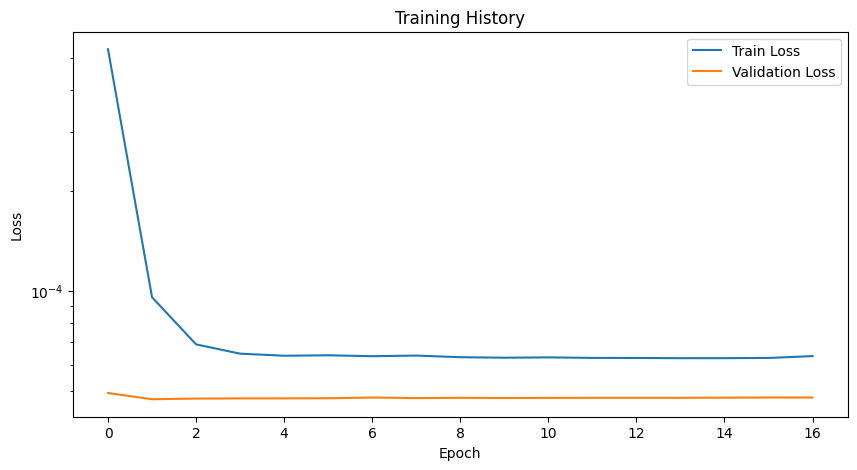

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.yscale('log')

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training History")

plt.legend()

plt.show()

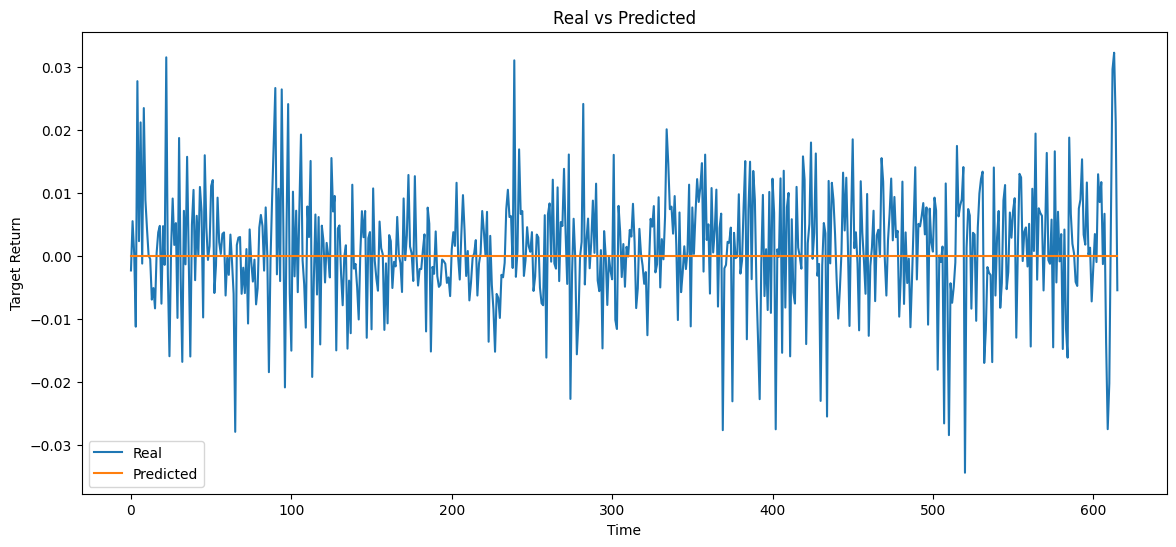

In [28]:
plt.figure(figsize=(14, 6))

plt.plot(
    y_test,
    label="Real"
)

plt.plot(
    y_pred_test.flatten(),
    label="Predicted"
)

plt.title("Real vs Predicted")

plt.xlabel("Time")

plt.ylabel("Target Return")

plt.legend()

plt.show()

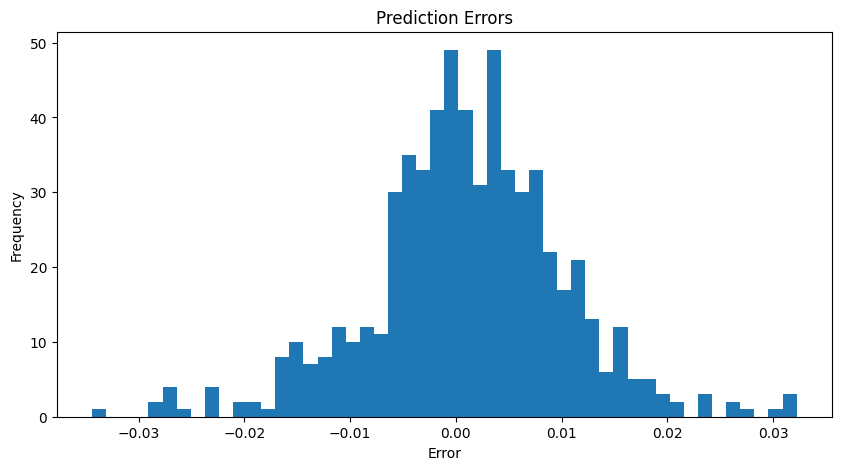

In [29]:
errors = (
    y_test -
    y_pred_test.flatten()
)

plt.figure(figsize=(10, 5))

plt.hist(
    errors,
    bins=50
)

plt.title("Prediction Errors")

plt.xlabel("Error")

plt.ylabel("Frequency")

plt.show()